Problem Statement

Organizations receive a high volume of IT and HR support tickets daily.
Manually reading, categorizing, and prioritizing each ticket is time-consuming, inconsistent, and not scalable.
Core Problem:
Automatically analyze the raw text of a support ticket to determine its category and priority, reducing manual effort and improving efficiency.

Solution

A hybrid system combining Machine Learning and rule-based techniques:

Ticket Classification (ML Model):
Uses NLP-based supervised learning to classify tickets into categories (e.g., Hardware, Access, HR Support).
Priority Assignment (Rule-Based):
Uses keyword matching and predefined rules to assign priority levels (High / Medium / Low).
Final Output:
Category
Priority
Confidence Score

This approach ensures faster, consistent, and scalable ticket triaging.    

 ML Pipeline 

1. **Data Ingestion**
   Load and structure ticket data using *Pandas* and *NumPy*.

2. **Text Preprocessing**
   Normalize text via lowercasing, regex-based noise removal, tokenization, stopword elimination, and lemmatization using *NLTK*.

3. **Feature Engineering**
   Transform text into numerical representations using **TF-IDF Vectorization** with optimized n-grams.

4. **Model Training**
   Train multiple classifiers:

   * **Logistic Regression** (baseline linear model)
   * **Linear SVM** (high-performance classifier)
   * **Multinomial Naive Bayes** (probabilistic approach)

5. **Evaluation**
   Assess performance using **accuracy, classification report, and confusion matrix**, with visual insights via *Matplotlib* and *Seaborn*.

6. **Prediction Pipeline**
   Integrate preprocessing + vectorization + model into a unified **Scikit-learn Pipeline** for efficient inference.

7. **Output**
   Generate predicted category with confidence insights and performance visualizations.


In [72]:
import pandas as pd
import numpy as np
import nltk
from nltk.corpus import stopwords
import re
import string
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix






In [73]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

In [74]:
df = pd.read_csv('all_tickets_processed_improved_v3.csv')
df            

,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous
...,...,...
47832,git space for a project issues with adding use...,Access
47833,error sent july error hi guys can you help out...,Miscellaneous
47834,connection issues sent tuesday july connection...,Hardware
47835,error cube reports sent tuesday july error hel...,HR Support


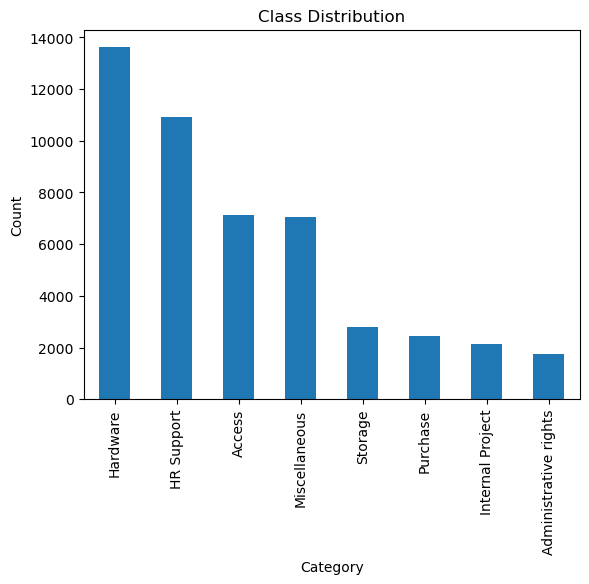

In [75]:
df = pd.read_csv('all_tickets_processed_improved_v3.csv')

plt.figure()
df['Topic_group'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()


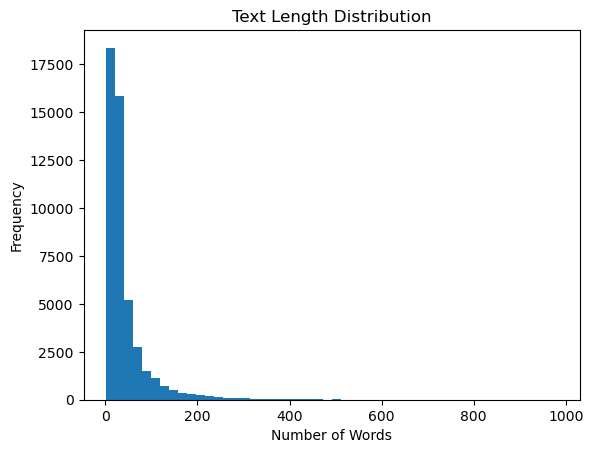

In [76]:
df['text_length'] = df['Document'].apply(lambda x: len(str(x).split()))

plt.figure()
plt.hist(df['text_length'], bins=50)
plt.title("Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()


In [77]:
df = df[['Document' ,'Topic_group']].dropna()

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47837 entries, 0 to 47836
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Document     47837 non-null  object
 1   Topic_group  47837 non-null  object
dtypes: object(2)
memory usage: 747.6+ KB


In [79]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [84]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = text.split()
    text = [lemmatizer.lemmatize(word) for word in text if word not in stop_words]
    return " ".join(text)
df['clean_text'] = df['Document'].apply(clean_text)    

In [86]:


X = df['clean_text']
y = df['Topic_group']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
# X_train, X_test, y_train, y_test = train_test_split( df['clean_text'],df['Topic_group'],test_size = 0.2, random_state = 42, stratify= df['Topic_group'])

In [87]:
tfidf = TfidfVectorizer(
    max_features = 10000,
    ngram_range = (1,2),
    min_df = 3
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

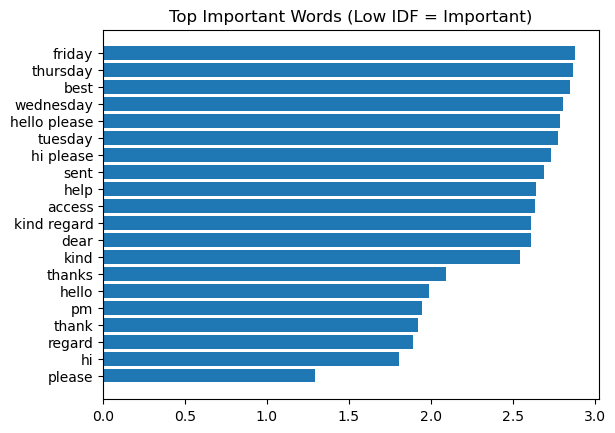

In [88]:
feature_names = tfidf.get_feature_names_out()
idf_scores = tfidf.idf_

top_indices = idf_scores.argsort()[:20]
top_words = [feature_names[i] for i in top_indices]

plt.figure()
plt.barh(top_words, idf_scores[top_indices])
plt.title("Top Important Words (Low IDF = Important)")
plt.show()


In [89]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize model
lr_model = LogisticRegression(max_iter=2000)

# Train
lr_model.fit(X_train_tfidf, y_train)

# Predict
lr_preds = lr_model.predict(X_test_tfidf)

# Evaluate
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_preds))
print("\nClassification Report:\n", classification_report(y_test, lr_preds))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, lr_preds))


Logistic Regression Accuracy: 0.8546195652173914

Classification Report:
                        precision    recall  f1-score   support

               Access       0.91      0.88      0.90      1425
Administrative rights       0.89      0.61      0.72       352
           HR Support       0.86      0.87      0.86      2183
             Hardware       0.79      0.89      0.84      2724
     Internal Project       0.93      0.81      0.87       424
        Miscellaneous       0.83      0.82      0.83      1412
             Purchase       0.97      0.87      0.92       493
              Storage       0.93      0.82      0.87       555

             accuracy                           0.85      9568
            macro avg       0.89      0.82      0.85      9568
         weighted avg       0.86      0.85      0.85      9568


Confusion Matrix:
 [[1251    3   34   92    3   38    1    3]
 [   9  216   10  106    1    9    1    0]
 [  32    3 1895  177    6   60    1    9]
 [  49   15  110 2

In [90]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize model
svm_model = LinearSVC()

# Train
svm_model.fit(X_train_tfidf, y_train)

# Predict
svm_preds = svm_model.predict(X_test_tfidf)

# Evaluate
print("Linear SVM Accuracy:", accuracy_score(y_test, svm_preds))
print("\nClassification Report:\n", classification_report(y_test, svm_preds))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, svm_preds))


Linear SVM Accuracy: 0.8582775919732442

Classification Report:
                        precision    recall  f1-score   support

               Access       0.90      0.90      0.90      1425
Administrative rights       0.84      0.68      0.75       352
           HR Support       0.87      0.86      0.86      2183
             Hardware       0.82      0.87      0.84      2724
     Internal Project       0.91      0.87      0.89       424
        Miscellaneous       0.83      0.82      0.82      1412
             Purchase       0.95      0.89      0.92       493
              Storage       0.91      0.87      0.89       555

             accuracy                           0.86      9568
            macro avg       0.88      0.84      0.86      9568
         weighted avg       0.86      0.86      0.86      9568


Confusion Matrix:
 [[1282    3   31   68    6   28    2    5]
 [   9  240   11   81    1    8    0    2]
 [  33    8 1881  162   10   73    3   13]
 [  64   26  131 2362   10 

In [91]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize model
nb_model = MultinomialNB()

# Train
nb_model.fit(X_train_tfidf, y_train)

# Predict
nb_preds = nb_model.predict(X_test_tfidf)

# Evaluate
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_preds))
print("\nClassification Report:\n", classification_report(y_test, nb_preds))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, nb_preds))


Naive Bayes Accuracy: 0.7872073578595318

Classification Report:
                        precision    recall  f1-score   support

               Access       0.87      0.79      0.83      1425
Administrative rights       0.94      0.29      0.45       352
           HR Support       0.84      0.78      0.81      2183
             Hardware       0.68      0.91      0.78      2724
     Internal Project       0.96      0.61      0.75       424
        Miscellaneous       0.76      0.75      0.76      1412
             Purchase       0.97      0.84      0.90       493
              Storage       0.95      0.69      0.80       555

             accuracy                           0.79      9568
            macro avg       0.87      0.71      0.76      9568
         weighted avg       0.81      0.79      0.78      9568


Confusion Matrix:
 [[1120    1   46  193    3   59    0    3]
 [   8  103    4  226    0   10    1    0]
 [  53    0 1713  321    5   81    0   10]
 [  61    4   72 2480    3

In [92]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC(),
    "Naive Bayes": MultinomialNB()
}

best_model = None
best_acc = 0

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds)

    if acc > best_acc:
        best_acc = acc
        best_model = model


In [93]:
results = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)

    acc = accuracy_score(y_test, preds)
    results[name] = acc

    print(f"\n{name} Accuracy: {acc}")
 



Logistic Regression Accuracy: 0.8546195652173914

Linear SVM Accuracy: 0.8582775919732442

Naive Bayes Accuracy: 0.7872073578595318


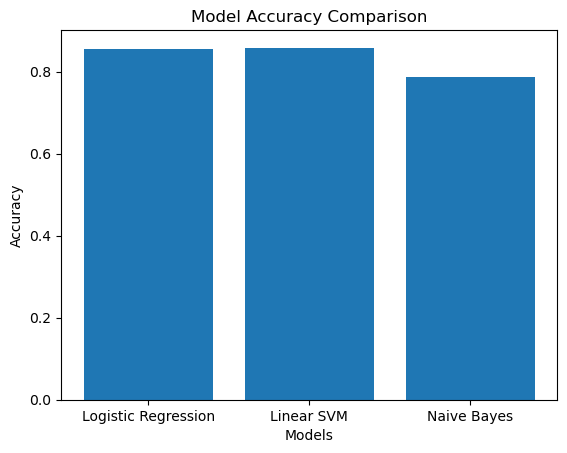

In [94]:
plt.figure()
plt.bar(results.keys(), results.values())
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()


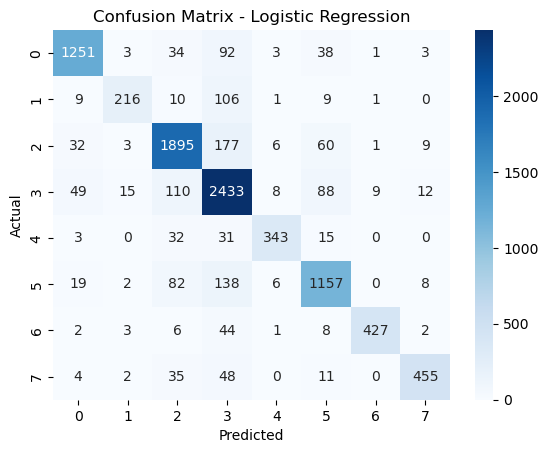

In [95]:
import seaborn as sns

cm = confusion_matrix(y_test, lr_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [96]:
from sklearn.model_selection import cross_val_score

for name, model in models.items():
    scores = cross_val_score(model, X_train_tfidf, y_train, cv=5)
    print(f"{name} CV Accuracy: {scores.mean():.4f}")


Logistic Regression CV Accuracy: 0.8491
Linear SVM CV Accuracy: 0.8501
Naive Bayes CV Accuracy: 0.7769


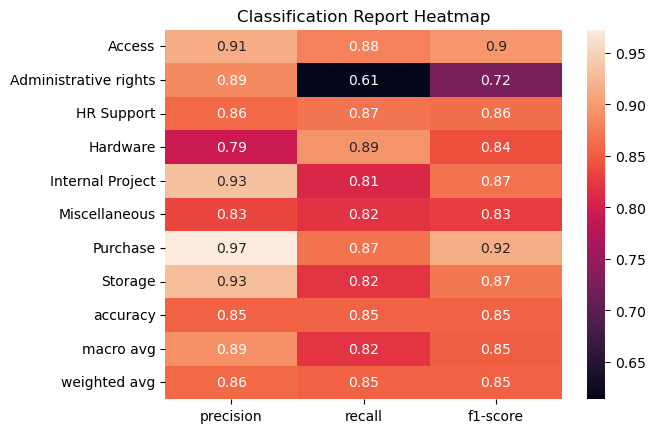

In [97]:
report = classification_report(y_test, lr_preds, output_dict=True)
sns.heatmap(pd.DataFrame(report).iloc[:-1, :].T, annot=True)
plt.title("Classification Report Heatmap")
plt.show()


In [98]:
def predict_ticket(text):
    cleaned = clean_text(text)
    vector = tfidf.transform([cleaned])
    category = best_model.predict(vector)[0]
    priority = assign_priority(text)
    return category, priority

In [99]:
def assign_priority(text):
    text = text.lower()

    high_keywords = ["urgent", "error", "down", "not working", "crash", "fail", "issue"]
    medium_keywords = ["password", "login", "reset", "slow", "delay"]

    if any(word in text for word in high_keywords):
        return "High"
    elif any(word in text for word in medium_keywords):
        return "Medium"
    else:
        return "Low"

In [100]:
sample = "My system is down and I cannot access my account"
print("\nPrediction:", predict_ticket(sample))


Prediction: ('Hardware', 'High')


In [105]:
import pickle

with open("lr_model.pkl", "wb") as f:
    pickle.dump(lr_model, f)

with open("svm_model.pkl", "wb") as f:
    pickle.dump(svm_model, f)

with open("nb_model.pkl", "wb") as f:
    pickle.dump(nb_model, f)

with open("tfidf.pkl", "wb") as f:
    pickle.dump(tfidf, f)
